# 3. Preprocessing & Feature Engineering
**Target:** `temp` (Daily Temperature °C)  
---

## 3.1 Setup

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/rainfall.csv')
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
df = df.sort_values('datetime').reset_index(drop=True)

TARGET   = 'temp'
NUM_COLS = ['temp', 'dew', 'humidity', 'sealevelpressure',
            'winddir', 'solarradiation', 'windspeed']

print(f'Raw data : {df.shape[0]:,} observations  |  {df.shape[1]} original variables')
print(f'Period   : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
df.head(3)

Raw data : 1,781 observations  |  10 original variables
Period   : 2016-01-01 → 2020-11-15


,datetime,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
0,2016-01-01,28.4,11.9,37.8,1016.4,147.5,216.1,16.6,0,0
1,2016-01-02,26.8,13.0,44.8,1017.2,110.3,215.7,16.6,0,0
2,2016-01-03,25.5,14.6,52.8,1015.7,145.3,221.1,18.4,0,0


---
# PART A — PREPROCESSING

## 3.2 Duplicate Check

In [24]:
n_dup_rows = df.duplicated().sum()
n_dup_date = df['datetime'].duplicated().sum()
full_range    = pd.date_range(start=df['datetime'].min(),
                               end=df['datetime'].max(), freq='D')
missing_dates = full_range.difference(df['datetime'])

print('=== Duplicate Check ===')
print(f'  Duplicate rows     : {n_dup_rows}')
print(f'  Duplicate datetime : {n_dup_date}')
print(f'  Missing dates      : {len(missing_dates)}')
if len(missing_dates) > 0:
    print(f'  → Missing: {missing_dates.tolist()}')

if n_dup_rows == 0 and n_dup_date == 0 and len(missing_dates) == 0:
    print('\n✓ No duplicates. Time index is continuous.')
else:
    df = df.drop_duplicates(subset='datetime').reset_index(drop=True)
    print('\n→ Duplicates removed.')

=== Duplicate Check ===
  Duplicate rows     : 0
  Duplicate datetime : 0
  Missing dates      : 0

✓ No duplicates. Time index is continuous.


## 3.3 Missing Values

In [25]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})

print('=== Missing Values Report ===')
print(missing_df.to_string())

if missing.sum() > 0:
    df[NUM_COLS] = df[NUM_COLS].interpolate(method='linear')
    print(f'\n→ Applied linear interpolation on {missing.sum()} missing values.')
else:
    print('\n✓ No missing values. No imputation needed.')

=== Missing Values Report ===
                  Missing Count  Missing (%)
datetime                      0          0.0
temp                          0          0.0
dew                           0          0.0
humidity                      0          0.0
sealevelpressure              0          0.0
winddir                       0          0.0
solarradiation                0          0.0
windspeed                     0          0.0
precipprob                    0          0.0
preciptype                    0          0.0

✓ No missing values. No imputation needed.


## 3.4 Outlier Detection & Treatment

In [26]:
outlier_report = []
for col in NUM_COLS:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask   = (df[col] < lower) | (df[col] > upper)
    outlier_report.append({
        'Variable'   : col,
        'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2),
        'N Outliers' : int(mask.sum()),
        'Outlier %'  : round(mask.mean() * 100, 2)
    })

print('=== Outlier Report (IQR Method) ===')
print(pd.DataFrame(outlier_report).to_string(index=False))

=== Outlier Report (IQR Method) ===
        Variable  Lower Fence  Upper Fence  N Outliers  Outlier %
            temp        23.45        33.45          23       1.29
             dew         7.30        36.10           7       0.39
        humidity        23.20       116.00           0       0.00
sealevelpressure       997.80      1020.20           3       0.17
         winddir        47.90       356.70           0       0.00
  solarradiation        74.90       394.10           8       0.45
       windspeed         9.10        33.90          33       1.85


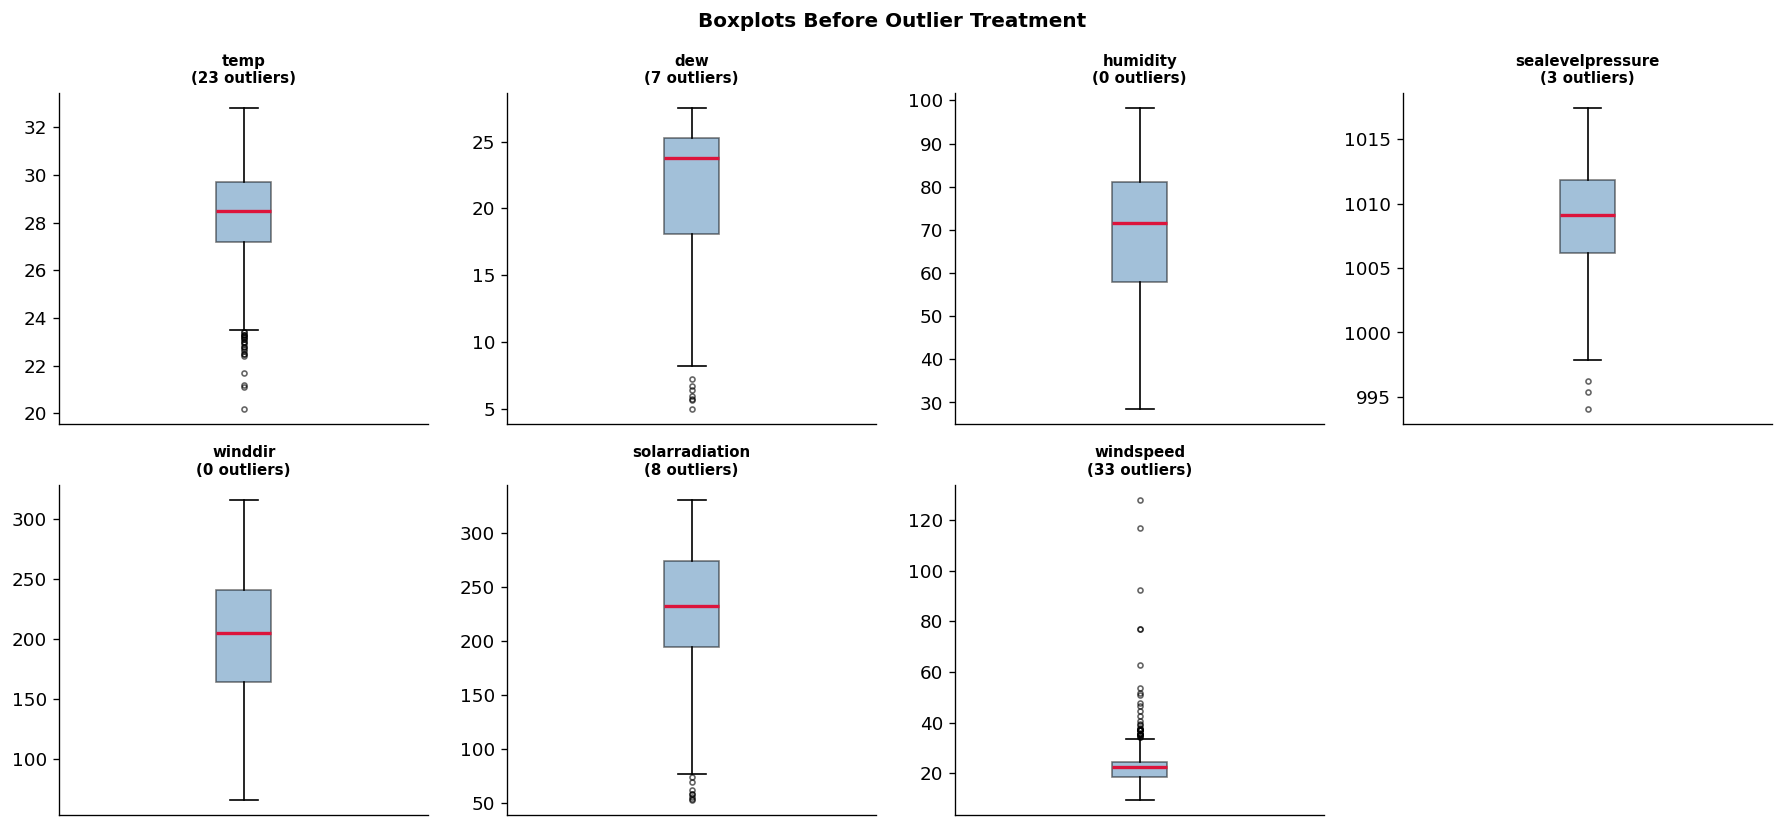

In [27]:
# Boxplots before treatment
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    n_out  = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    bp = axes[i].boxplot(df[col], patch_artist=True,
                          medianprops=dict(color='crimson', linewidth=2),
                          flierprops=dict(marker='o', markersize=3,
                                          color='tomato', alpha=0.6))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.5)
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontsize=9, fontweight='bold')
    axes[i].set_xticks([])
axes[-1].set_visible(False)
fig.suptitle('Boxplots Before Outlier Treatment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Winsorization at p1–p99
# temp    KEPT: genuine cold-season events (Jan–Feb)
# windspeed KEPT: natural monsoon wind events (Jun–Sep)
df_clean = df.copy()
winsorize_cols = ['solarradiation', 'sealevelpressure', 'dew']

for col in winsorize_cols:
    lo = df_clean[col].quantile(0.01)
    hi = df_clean[col].quantile(0.99)
    n  = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    print(f'  {col:20s}: clipped {n} values → [{lo:.2f}, {hi:.2f}]')

print(f'\n→ temp      : outliers KEPT (genuine cold-season readings Jan–Feb)')
print(f'→ windspeed : outliers KEPT (natural monsoon wind events Jun–Sep)')
print(f'✓ Shape after cleaning: {df_clean.shape}')

  solarradiation      : clipped 36 values → [84.74, 323.78]
  sealevelpressure    : clipped 35 values → [1000.40, 1015.72]
  dew                 : clipped 30 values → [9.60, 26.60]

→ temp      : outliers KEPT (genuine cold-season readings Jan–Feb)
→ windspeed : outliers KEPT (natural monsoon wind events Jun–Sep)
✓ Shape after cleaning: (1781, 10)


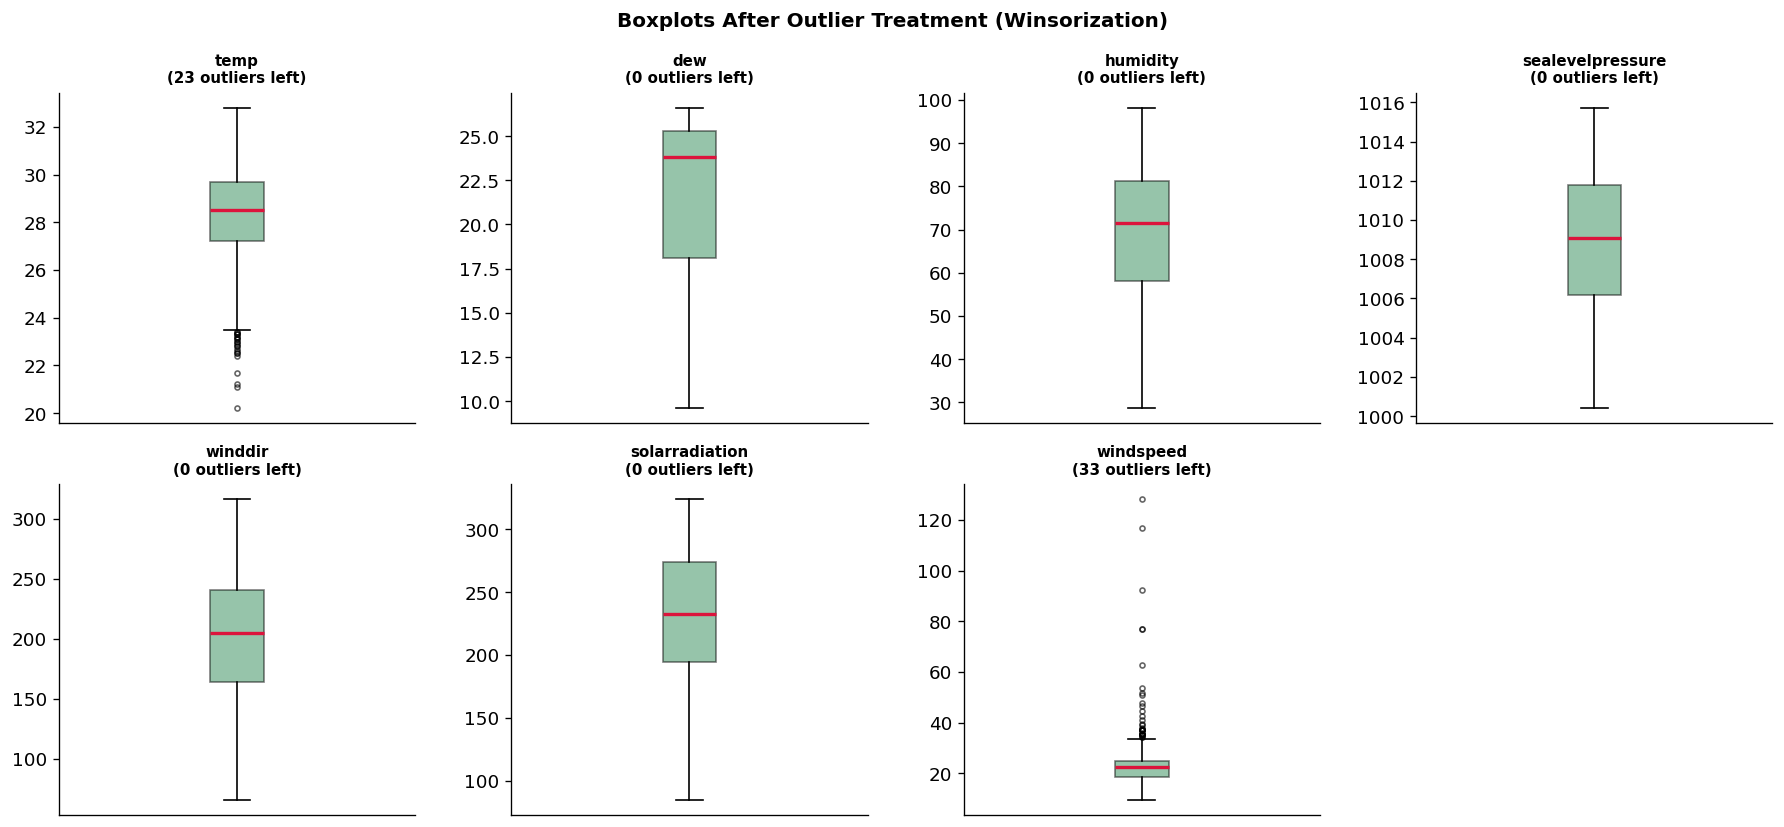

In [29]:
# Boxplots after treatment
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    q1, q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    iqr    = q3 - q1
    n_out  = ((df_clean[col] < q1-1.5*iqr) | (df_clean[col] > q3+1.5*iqr)).sum()
    bp = axes[i].boxplot(df_clean[col], patch_artist=True,
                          medianprops=dict(color='crimson', linewidth=2),
                          flierprops=dict(marker='o', markersize=3,
                                          color='tomato', alpha=0.6))
    bp['boxes'][0].set_facecolor('seagreen')
    bp['boxes'][0].set_alpha(0.5)
    axes[i].set_title(f'{col}\n({n_out} outliers left)', fontsize=9, fontweight='bold')
    axes[i].set_xticks([])
axes[-1].set_visible(False)
fig.suptitle('Boxplots After Outlier Treatment (Winsorization)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# PART B — FEATURE ENGINEERING

Features được chia theo model sẽ dùng:

| Feature group | SARIMA | SARIMAX | XGBoost |
|---|---|---|---|
| Time features (month, season, sin/cos) | ❌ | ❌ | ✅ |
| Exogenous lags (dew_lag1, pressure_lag1) | ❌ | ✅ | ✅ |
| Temp lag (lag1, lag7) | ❌ | ❌ | ✅ |
| Rolling mean 7-day | ❌ | ❌ | ✅ |

> Scaling deferred to modeling notebook (fit on train set only).

## 3.5 Time Features

In [30]:
df_fe = df_clean.copy()

# Basic time features
df_fe['year']      = df_fe['datetime'].dt.year
df_fe['month']     = df_fe['datetime'].dt.month
df_fe['quarter']   = df_fe['datetime'].dt.quarter
df_fe['dayofyear'] = df_fe['datetime'].dt.dayofyear

# Season label (Vietnam climate)
def get_season(month):
    if month in [12, 1, 2]:     return 0  # Dry-Cool
    elif month in [3, 4, 5]:    return 1  # Hot-Dry
    elif month in [6, 7, 8, 9]: return 2  # Rainy
    else:                        return 3  # Transitional

df_fe['season'] = df_fe['month'].apply(get_season)
season_map = {0:'Dry-Cool', 1:'Hot-Dry', 2:'Rainy', 3:'Transitional'}

# Fourier features — smooth cyclical encoding
df_fe['sin_doy']   = np.sin(2 * np.pi * df_fe['dayofyear'] / 365)
df_fe['cos_doy']   = np.cos(2 * np.pi * df_fe['dayofyear'] / 365)
df_fe['sin_month'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['cos_month'] = np.cos(2 * np.pi * df_fe['month'] / 12)

# Linear time index
df_fe['time_index'] = np.arange(len(df_fe))

time_cols = ['year','month','quarter','dayofyear','season',
             'sin_doy','cos_doy','sin_month','cos_month','time_index']
print('=== Time Features Created ===')
print(df_fe[['datetime'] + time_cols].head(5).to_string(index=False))
print(f'\nSeason distribution:')
print(df_fe['season'].map(season_map).value_counts().to_string())

=== Time Features Created ===
  datetime  year  month  quarter  dayofyear  season  sin_doy  cos_doy  sin_month  cos_month  time_index
2016-01-01  2016      1        1          1       0 0.017213 0.999852        0.5   0.866025           0
2016-01-02  2016      1        1          2       0 0.034422 0.999407        0.5   0.866025           1
2016-01-03  2016      1        1          3       0 0.051620 0.998667        0.5   0.866025           2
2016-01-04  2016      1        1          4       0 0.068802 0.997630        0.5   0.866025           3
2016-01-05  2016      1        1          5       0 0.085965 0.996298        0.5   0.866025           4

Season distribution:
season
Rainy           610
Hot-Dry         460
Dry-Cool        421
Transitional    290


## 3.6 Lag Features

In [31]:
# --- Exogenous variable lags (for SARIMAX + XGBoost) ---
for col in ['dew', 'sealevelpressure']:
    df_fe[f'{col}_lag1'] = df_fe[col].shift(1)

# --- Temp lag features (for XGBoost only) ---
# NOT used in SARIMA/SARIMAX — they handle autocorrelation via AR(p) terms
df_fe['temp_lag1'] = df_fe[TARGET].shift(1)
df_fe['temp_lag7'] = df_fe[TARGET].shift(7)

# Summary
lag_cols = ['dew_lag1', 'sealevelpressure_lag1', 'temp_lag1', 'temp_lag7']
print('=== Lag Features — Correlation with temp ===')
corr_lags = df_fe[lag_cols].corrwith(df_fe[TARGET]).round(4)
print(corr_lags.to_string())

print(f'\nSample:')
print(df_fe[['datetime', TARGET] + lag_cols].iloc[7:12].to_string(index=False))

=== Lag Features — Correlation with temp ===
dew_lag1                 0.5161
sealevelpressure_lag1   -0.3185
temp_lag1                0.9081
temp_lag7                0.6302

Sample:
  datetime  temp  dew_lag1  sealevelpressure_lag1  temp_lag1  temp_lag7
2016-01-08  26.6      17.0                 1015.1       26.1       28.4
2016-01-09  26.3      16.5                 1015.4       26.6       26.8
2016-01-10  26.0      13.5                 1013.8       26.3       25.5
2016-01-11  26.1      12.5                 1014.2       26.0       26.4
2016-01-12  25.1      14.6                 1014.3       26.1       27.1


## 3.7 Rolling Mean (XGBoost only)

=== Rolling Mean Feature ===
temp_rollmean7 — correlation with temp: 0.8013


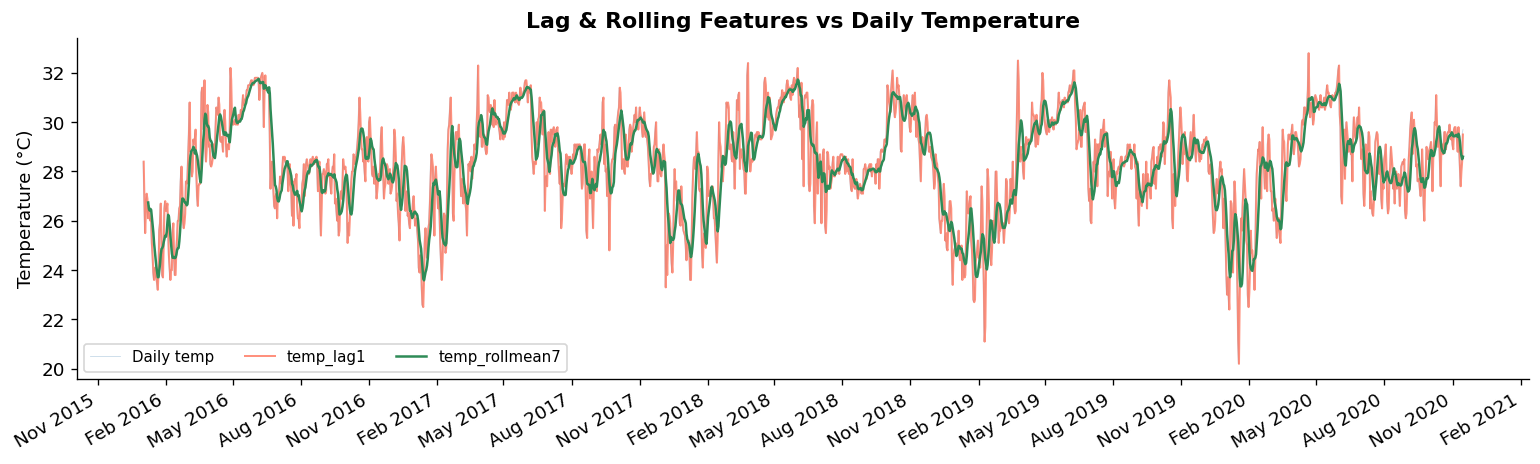

In [ ]:
# Only 1 window to avoid multicollinearity
# shift(1) before rolling → prevents data leakage
df_fe['temp_rollmean7'] = df_fe[TARGET].shift(1).rolling(7).mean()

print('=== Rolling Mean Feature ===')
print(f'temp_rollmean7 — correlation with temp: '
      f'{df_fe["temp_rollmean7"].corr(df_fe[TARGET]):.4f}')

# Visualize
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_fe['datetime'], df_fe[TARGET],
        color='steelblue', alpha=0.3, linewidth=0.5, label='Daily temp')
ax.plot(df_fe['datetime'], df_fe['temp_lag1'],
        color='tomato', linewidth=1.2, alpha=0.7, label='temp_lag1')
ax.plot(df_fe['datetime'], df_fe['temp_rollmean7'],
        color='seagreen', linewidth=1.5, label='temp_rollmean7')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Lag & Rolling Features vs Daily Temperature', fontweight='bold')
ax.legend(fontsize=9, ncol=3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3.8 Drop NaN & Save

In [33]:
n_before = len(df_fe)
df_fe    = df_fe.dropna().reset_index(drop=True)
n_after  = len(df_fe)

# Feature inventory
original_cols  = ['dew','humidity','sealevelpressure','winddir',
                  'solarradiation','windspeed','preciptype']
time_cols_     = ['year','month','quarter','dayofyear','season',
                  'sin_doy','cos_doy','sin_month','cos_month','time_index']
lag_cols_      = ['dew_lag1','sealevelpressure_lag1',   # SARIMAX + XGBoost
                  'temp_lag1','temp_lag7']               # XGBoost only
rolling_cols_  = ['temp_rollmean7']                     # XGBoost only

all_features = original_cols + time_cols_ + lag_cols_ + rolling_cols_

print(f'Rows before dropna : {n_before:,}')
print(f'Rows after  dropna : {n_after:,}  (dropped {n_before-n_after} rows)')
print(f'\n=== Final Feature Inventory ===')
print(f'  Original features        : {len(original_cols):>3}')
print(f'  Time features            : {len(time_cols_):>3}')
print(f'  Lag features             : {len(lag_cols_):>3}')
print(f'    └ exog lags (SARIMAX+XGB) : dew_lag1, sealevelpressure_lag1')
print(f'    └ temp lags (XGB only)    : temp_lag1, temp_lag7')
print(f'  Rolling features         : {len(rolling_cols_):>3}  (XGBoost only)')
print(f'  ───────────────────────────')
print(f'  TOTAL features           : {len(all_features):>3}')
print(f'  Target                   : {TARGET}')
print(f'  Final observations       : {n_after:,}')
print(f'\n  ⚠ Scaling: deferred to modeling notebook (train set only)')

df_fe.to_csv('rainfall_fe.csv', index=False)
print(f'\n✓ Saved → rainfall_fe.csv')

Rows before dropna : 1,781
Rows after  dropna : 1,774  (dropped 7 rows)

=== Final Feature Inventory ===
  Original features        :   7
  Time features            :  10
  Lag features             :   4
    └ exog lags (SARIMAX+XGB) : dew_lag1, sealevelpressure_lag1
    └ temp lags (XGB only)    : temp_lag1, temp_lag7
  Rolling features         :   1  (XGBoost only)
  ───────────────────────────
  TOTAL features           :  22
  Target                   : temp
  Final observations       : 1,774

  ⚠ Scaling: deferred to modeling notebook (train set only)

✓ Saved → rainfall_fe.csv


## 3.9 Summary

| Step | Action | Result |
|---|---|---|
| **Duplicate rows** | Checked | 0 duplicates |
| **Missing dates** | Checked | Time series continuous |
| **Missing values** | Checked | 0 missing |
| **Outliers** | Winsorize p1–p99 on solarradiation, sealevelpressure, dew | temp & windspeed kept intentionally |
| **Scaling** | ⏳ Deferred | Applied after train/test split in modeling |
| **Time features** | month, quarter, dayofyear, season, Fourier sin/cos | 10 features — XGBoost |
| **Exog lags** | dew_lag1, sealevelpressure_lag1 | 2 features — SARIMAX + XGBoost |
| **Temp lags** | temp_lag1, temp_lag7 | 2 features — XGBoost only |
| **Rolling mean** | temp_rollmean7 (1 window only) | 1 feature — XGBoost only |
| **Final dataset** | 1,774 obs × 25 features | Saved: `rainfall_fe.csv` |